-------------------------
Tokenization: To demonstrate how a piece of text is split into individual tokens according to the rules of a pre-trained Transformer model's tokenizer. This helps in understanding how text is processed before being fed into the model.

Token IDs Conversion: To show how these tokens are mapped to their corresponding numerical IDs, which are used by the model for computation. This step is crucial as models work with numerical data rather than raw text.

Encoding: To illustrate how the entire text is converted into a format that can be directly used by the model, including creating tensors that represent the token IDs.

Decoding: To demonstrate how numerical token IDs can be converted back into human-readable text, which helps in interpreting the model's outputs.

-----------------------------

In [1]:
#pip install transformers

In [1]:
from transformers import BertTokenizer

In [2]:
# Load pre-trained tokenizer for BERT
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', 
                                          cache_dir=r'D:\AI-DATASETS\07-Hugging-Face-Data')

In [3]:
# Sample text to tokenize
text = "Hello, yelahanka, how are you doing today, unforgettable, undesirable, Chat-Masala, dosa?"

In [4]:
# Tokenize the text, 
tokens = tokenizer.tokenize(text)
print("Tokens:", tokens)

Tokens: ['hello', ',', 'ye', '##lah', '##an', '##ka', ',', 'how', 'are', 'you', 'doing', 'today', ',', 'un', '##for', '##get', '##table', ',', 'und', '##es', '##ira', '##ble', ',', 'chat', '-', 'mas', '##ala', ',', 'dos', '##a', '?']


In [5]:
# Convert tokens to token IDs
token_ids = tokenizer.convert_tokens_to_ids(tokens)
print("Token IDs:", token_ids)

Token IDs: [7592, 1010, 6300, 14431, 2319, 2912, 1010, 2129, 2024, 2017, 2725, 2651, 1010, 4895, 29278, 18150, 10880, 1010, 6151, 2229, 7895, 3468, 1010, 11834, 1011, 16137, 7911, 1010, 9998, 2050, 1029]


In [6]:
# Convert text to token IDs directly
encodings = tokenizer(text)
print("Encodings:", encodings)

Encodings: {'input_ids': [101, 7592, 1010, 6300, 14431, 2319, 2912, 1010, 2129, 2024, 2017, 2725, 2651, 1010, 4895, 29278, 18150, 10880, 1010, 6151, 2229, 7895, 3468, 1010, 11834, 1011, 16137, 7911, 1010, 9998, 2050, 1029, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


In [7]:
# Decode token IDs back to text
decoded_text = tokenizer.decode(encodings['input_ids'][0])
print("Decoded Text:", decoded_text)

Decoded Text: [CLS]


---
### tiktokens
---

`tiktoken` is OpenAI’s tokenizer library. It’s used to break text into tokens, which are the units of text that models actually understand and count — not characters or words.

For English:

- 1 token ≈ ¾ word
- “OpenAI is amazing!” → 4 tokens

Models like GPT-3.5, GPT-4, etc., all process input and output based on token count, not character count.

In [8]:
#!pip install tiktoken --quiet

In [9]:
import tiktoken

# Use tokenizer for a specific model
model = "gpt-4"
enc = tiktoken.encoding_for_model(model)

In [10]:
# Try changing this text
text = "OpenAI's GPT-4 is amazing at understanding natural language!"

# Tokenize it
tokens = enc.encode(text)

# Show the tokens
print("Original Text:", text)
print("Number of Tokens:", len(tokens))
print("Token IDs:", tokens)
print("Decoded Tokens:", [enc.decode([t]) for t in tokens])


Original Text: OpenAI's GPT-4 is amazing at understanding natural language!
Number of Tokens: 14
Token IDs: [5109, 15836, 596, 480, 2898, 12, 19, 374, 8056, 520, 8830, 5933, 4221, 0]
Decoded Tokens: ['Open', 'AI', "'s", ' G', 'PT', '-', '4', ' is', ' amazing', ' at', ' understanding', ' natural', ' language', '!']


**Estimate prompt cost**

In [11]:
def estimate_cost(token_count, price_per_1k_tokens=0.01):
    return (token_count / 1000) * price_per_1k_tokens

# Estimate for our sample text
cost = estimate_cost(len(tokens))
print(f"Estimated Cost: ${cost:.6f}")


Estimated Cost: $0.000140


**Chunk long text for GPT input or embedding**

In [12]:
def chunk_text_by_tokens(text, chunk_size=100, overlap=20):
    token_ids = enc.encode(text)
    chunks = []
    
    for start in range(0, len(token_ids), chunk_size - overlap):
        end = start + chunk_size
        chunk_tokens = token_ids[start:end]
        chunk_text = enc.decode(chunk_tokens)
        chunks.append(chunk_text)
    
    return chunks

In [13]:
# Example long text
long_text = (
    "Machine learning involves training models on data to make predictions. "
    "There are supervised, unsupervised, and reinforcement learning methods. "
    "Feature engineering, model selection, and evaluation are key steps."
) * 5

In [14]:
long_text

'Machine learning involves training models on data to make predictions. There are supervised, unsupervised, and reinforcement learning methods. Feature engineering, model selection, and evaluation are key steps.Machine learning involves training models on data to make predictions. There are supervised, unsupervised, and reinforcement learning methods. Feature engineering, model selection, and evaluation are key steps.Machine learning involves training models on data to make predictions. There are supervised, unsupervised, and reinforcement learning methods. Feature engineering, model selection, and evaluation are key steps.Machine learning involves training models on data to make predictions. There are supervised, unsupervised, and reinforcement learning methods. Feature engineering, model selection, and evaluation are key steps.Machine learning involves training models on data to make predictions. There are supervised, unsupervised, and reinforcement learning methods. Feature engineer

In [15]:
chunks = chunk_text_by_tokens(long_text)

In [16]:
print(f"Number of chunks: {len(chunks)}")
for i, c in enumerate(chunks):
    print(f"\n--- Chunk {i+1} ---\n{c}")

Number of chunks: 3

--- Chunk 1 ---
Machine learning involves training models on data to make predictions. There are supervised, unsupervised, and reinforcement learning methods. Feature engineering, model selection, and evaluation are key steps.Machine learning involves training models on data to make predictions. There are supervised, unsupervised, and reinforcement learning methods. Feature engineering, model selection, and evaluation are key steps.Machine learning involves training models on data to make predictions. There are supervised, unsupervised, and reinforcement learning methods. Feature engineering, model

--- Chunk 2 ---
 make predictions. There are supervised, unsupervised, and reinforcement learning methods. Feature engineering, model selection, and evaluation are key steps.Machine learning involves training models on data to make predictions. There are supervised, unsupervised, and reinforcement learning methods. Feature engineering, model selection, and evaluation ar

**Visualize token counts vs model limits**

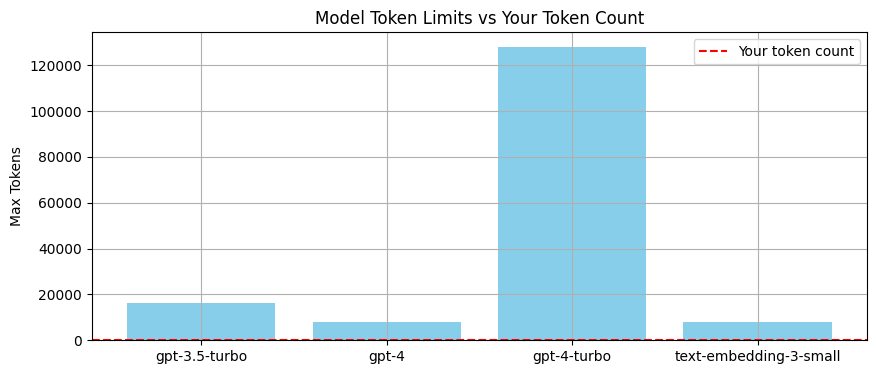

In [17]:
import matplotlib.pyplot as plt

models = {
    "gpt-3.5-turbo": 16385,
    "gpt-4": 8192,
    "gpt-4-turbo": 128000,
    "text-embedding-3-small": 8192
}

plt.figure(figsize=(10, 4))
plt.bar(models.keys(), models.values(), color='skyblue')
plt.axhline(len(tokens), color='red', linestyle='--', label="Your token count")
plt.title("Model Token Limits vs Your Token Count")
plt.ylabel("Max Tokens")
plt.legend()
plt.grid(True)
plt.show()
